# Product Satisfaction from Review Text

This is an **independent experimental extension**. It does not improve the
selfie colour matcher directly. The goal is to predict whether a review is
positive from its text using a TF-IDF and logistic-regression baseline.

The split is grouped by product so that reviews for the same product do
not appear in both training and test sets.


## 1. Setup


In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPOSITORY_URL = "https://github.com/amafteeva/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-.git"


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


project_root = find_project_root(Path.cwd())

if project_root is None and "google.colab" in sys.modules:
    if "YOUR_USERNAME" in REPOSITORY_URL:
        raise ValueError(
            "Replace YOUR_USERNAME in REPOSITORY_URL after publishing the project to GitHub."
        )
    project_root = Path("/content/foundation-shade-recommender")
    if not project_root.exists():
        subprocess.run(["git", "clone", REPOSITORY_URL, str(project_root)], check=True)

if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the project folder.")

os.chdir(project_root)

# Connect the local `foundation_matcher` package (src/ layout) so the
# imports below resolve even if the editable install has not been run.
src_path = project_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Install the package and its dependencies. Non-fatal: if a dependency
# wheel is unavailable the local package is still importable via src_path.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "."],
    check=False,
)
if result.returncode != 0:
    print("Warning: `pip install -e .` failed; using src/ on sys.path instead.")

import importlib.util

if importlib.util.find_spec("foundation_matcher") is None:
    raise ModuleNotFoundError(
        f"foundation_matcher not found. Expected package at {src_path}."
    )

print("Project root:", project_root)
print("foundation_matcher connected from:", src_path)


Project root: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-
foundation_matcher connected from: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-/src


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

from foundation_matcher.config import LUXXIFY_PRODUCT_URL, LUXXIFY_REVIEW_URL
from foundation_matcher.review_model import (
    attach_product_metadata,
    build_review_classifier,
    evaluate_review_classifier,
    grouped_train_test_split,
    prepare_review_data,
    summarize_luxxify_products,
    summarize_luxxify_reviews,
)
from foundation_matcher.visualization import (
    plot_category_distribution,
    plot_price_distribution,
    plot_rating_distribution,
    plot_review_length_distribution,
)


## 2. Load raw data and explore it

Two separate Luxxify exports are used: the reviews (text + rating) and a
per-product export (category, price, brand). Both are inspected here
*before* any cleaning, since `prepare_review_data` silently drops most of
the reviews export (only reviews with written text survive) and
`attach_product_metadata` only covers products that exist in both files.

Ratings of 4 or 5 are labelled positive. Because the dataset is strongly
imbalanced, later evaluation includes balanced accuracy, class-specific
precision/recall/F1, ROC AUC, and average precision—not accuracy alone.


In [3]:
makeup_reviews = pd.read_csv(LUXXIFY_REVIEW_URL, low_memory=False)
makeup_products = pd.read_csv(LUXXIFY_PRODUCT_URL, low_memory=False)

print("Raw review shape:", makeup_reviews.shape)
print("Raw product shape:", makeup_products.shape)

review_summary = summarize_luxxify_reviews(makeup_reviews)
product_summary = summarize_luxxify_products(makeup_products)

print("\nReview export summary:")
display(pd.Series(review_summary, name="value").to_frame())

print("\nProduct export summary:")
display(pd.Series(product_summary, name="value").to_frame())


Raw review shape: (314029, 27)
Raw product shape: (1373, 35)

Review export summary:


,value
total_reviews,314029.000
reviews_with_text,52164.000
text_missing_rate,0.834
median_review_word_count,36.000
verified_buyer_rate,0.032
median_reviews_per_product,55.000
max_reviews_per_product,6455.000



Product export summary:


,value
total_products,1373.000
total_categories,12.000
category_missing_rate,0.016
brand_missing_rate,0.323
price_missing_rate,0.000
num_shades_missing_rate,0.953
price_median,26.000


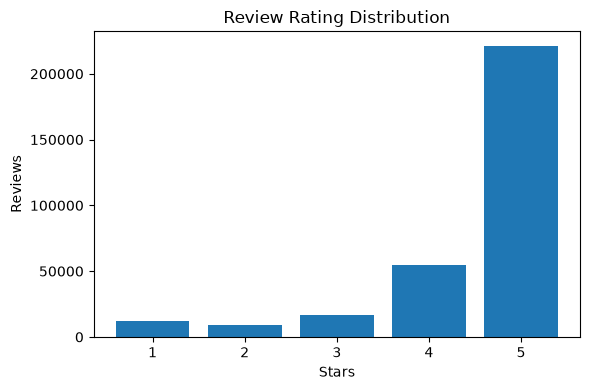

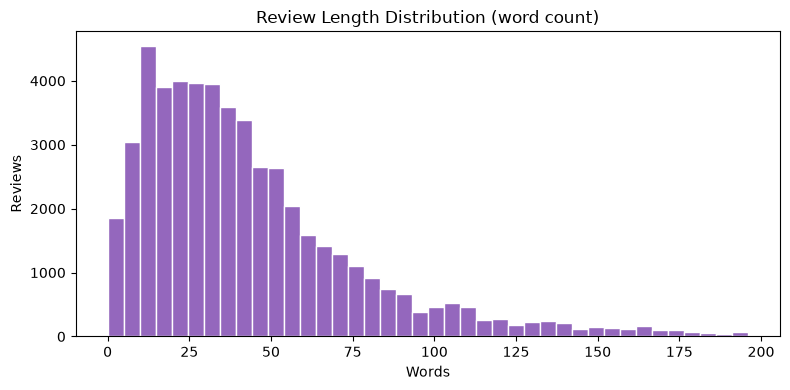

In [4]:
plot_rating_distribution(makeup_reviews)
plt.show()

plot_review_length_distribution(makeup_reviews)
plt.show()


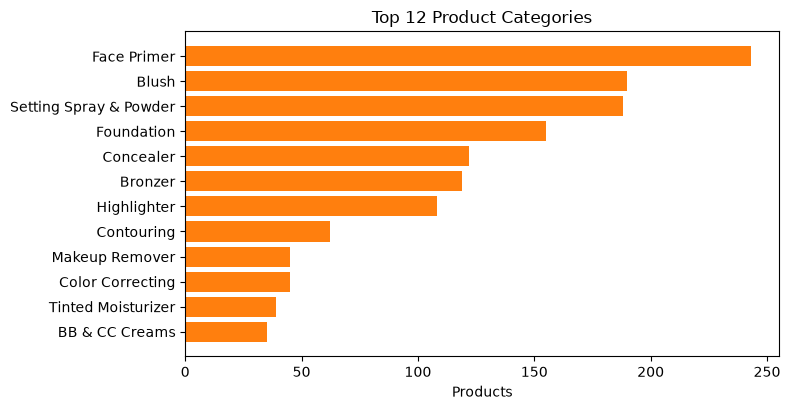

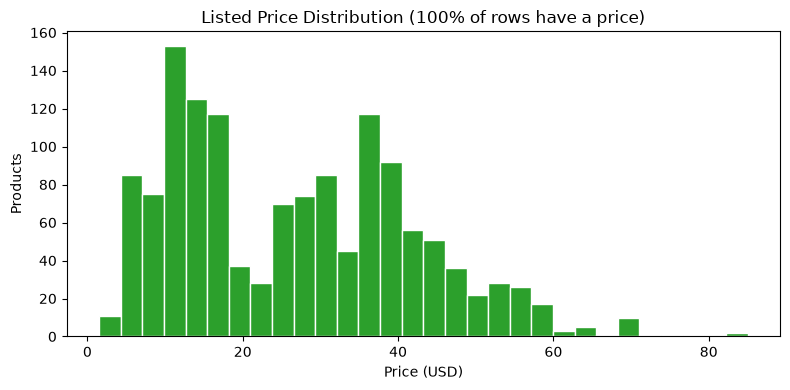

In [5]:
plot_category_distribution(makeup_products)
plt.show()

plot_price_distribution(makeup_products, row_label="Products", title="Listed Price Distribution")
plt.show()


## 3. Clean the reviews and attach product metadata

`prepare_review_data` keeps only reviews with written text and a valid
rating. `attach_product_metadata` then joins `category`, `price`, and
`brand` from the product export via the shared `product_link_id`, so the
classifier can use more than review text alone.


In [6]:
# This export stores the review body in `comments`, the star rating in
# `rating`, and the product identifier in `product_link_id`.
review_ml = prepare_review_data(
    makeup_reviews,
    text_column="comments",
    rating_column="rating",
    group_column="product_link_id",
    positive_threshold=4,
)

# Attach per-product metadata (category, price, brand) from the separate
# Luxxify product export via the shared product_link_id key.
review_ml = attach_product_metadata(review_ml, makeup_products)

print("Prepared examples:", len(review_ml))
print(
    "Product-metadata null rates:",
    review_ml[["category", "price", "brand"]].isna().mean().round(3).to_dict(),
)
display(
    review_ml["positive_review"]
    .value_counts()
    .rename_axis("class")
    .to_frame("count")
    .assign(proportion=lambda table: table["count"] / table["count"].sum())
)


Prepared examples: 28185
Product-metadata null rates: {'category': 0.041, 'price': 0.024, 'brand': 0.337}


,count,proportion
class,,
1,20772,0.736988
0,7413,0.263012


### Optional Colab-sized sample

The full dataset can be used by setting `MAX_ROWS = None`. The default
keeps the baseline practical on a standard Colab runtime while retaining
both classes. This is a development sample, not a final benchmark.


In [7]:
MAX_ROWS = 120_000

if MAX_ROWS is not None and len(review_ml) > MAX_ROWS:
    fraction = MAX_ROWS / len(review_ml)
    review_ml = (
        review_ml.groupby("positive_review", group_keys=False)
        .sample(frac=fraction, random_state=42)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

print("Examples used:", len(review_ml))


Examples used: 28185


## 4. Make a product-grouped train/test split


In [8]:
FEATURE_COLUMNS = ("review_text", "category", "price", "brand")

(
    X_train,
    X_test,
    y_train,
    y_test,
    train_groups,
    test_groups,
) = grouped_train_test_split(review_ml, feature_columns=FEATURE_COLUMNS)

product_overlap = set(train_groups).intersection(test_groups)
assert not product_overlap, "Product leakage detected."

print(f"Training reviews: {len(X_train):,}")
print(f"Testing reviews: {len(X_test):,}")
print("Products appearing in both sets:", len(product_overlap))
print("Training positive rate:", f"{y_train.mean():.1%}")
print("Testing positive rate:", f"{y_test.mean():.1%}")


Training reviews: 22,544
Testing reviews: 5,641
Products appearing in both sets: 0
Training positive rate: 73.7%
Testing positive rate: 73.7%


## 5. Train the baseline


In [9]:
review_classifier = build_review_classifier(
    max_features=40_000,
    minimum_document_frequency=5,
    categorical_columns=("category", "brand"),
    numeric_columns=("price",),
)

review_classifier.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 6. Evaluate with imbalance-aware metrics


Always-positive accuracy: 0.737


,score
accuracy,0.880
balanced_accuracy,0.870
precision,0.943
recall,0.891
f1,0.916
roc_auc,0.934
average_precision,0.972


,precision,recall,f1-score,support
negative,0.736,0.849,0.788,1485.00
positive,0.943,0.891,0.916,4156.00
accuracy,0.880,0.880,0.880,0.88
macro avg,0.839,0.870,0.852,5641.00
weighted avg,0.888,0.880,0.883,5641.00


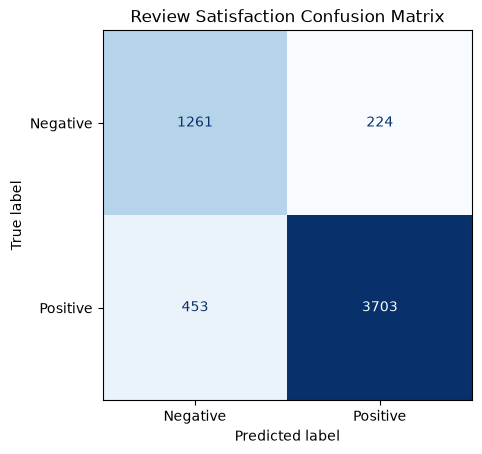

In [10]:
metrics, classification_table, confusion = evaluate_review_classifier(
    review_classifier,
    X_test,
    y_test,
)

always_positive_accuracy = y_test.mean()
print("Always-positive accuracy:", f"{always_positive_accuracy:.3f}")
display(metrics.to_frame().round(3))
display(classification_table.round(3))

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Negative", "Positive"],
).plot(cmap="Blues", colorbar=False)
plt.title("Review Satisfaction Confusion Matrix")
plt.grid(False)
plt.show()


## 7. Inspect influential words, phrases, and product features

Feature names are prefixed by which part of the ColumnTransformer produced
them: `text__` for TF-IDF terms, `categorical__` for one-hot category/brand
indicators, and `numeric__price` for the scaled price feature.


In [11]:
feature_names = review_classifier.named_steps["features"].get_feature_names_out()
coefficients = review_classifier.named_steps["classifier"].coef_[0]

coefficient_table = pd.DataFrame(
    {"term": feature_names, "coefficient": coefficients}
)

print("Terms/features most associated with negative reviews")
display(coefficient_table.nsmallest(15, "coefficient"))

print("Terms/features most associated with positive reviews")
display(coefficient_table.nlargest(15, "coefficient"))


Terms/features most associated with negative reviews


,term,coefficient
16346,text__unfortunately,-5.646201
4073,text__disappointed,-5.252017
16996,text__wanted love,-4.995429
786,text__bad,-4.767128
13197,text__returning,-4.576237
13190,text__return,-4.408551
13194,text__returned,-4.349556
15504,text__terrible,-4.249625
771,text__awful,-4.231817
1754,text__broke,-4.221964


Terms/features most associated with positive reviews


,term,coefficient
9249,text__love,9.276431
11210,text__perfect,7.344850
404,text__amazing,6.220815
6720,text__great,5.902367
1013,text__best,5.565171
10355,text__natural,4.576790
4591,text__easy,4.258765
900,text__beautiful,3.995430
6214,text__gives,3.933910
7111,text__helps,3.906495


## 8. Interpretation and next steps

Compare the trained model with the always-positive baseline. High raw
accuracy is not impressive when most reviews are positive. Balanced
accuracy and negative-class recall reveal whether the classifier learns
useful minority-class signals.

Ratings are used to create the label, so this experiment predicts
rating-derived sentiment rather than long-term product satisfaction.

This version adds `category`, `price`, and `brand` from the Luxxify product
export alongside review text, while still preserving product-level
separation between training and evaluation. `brand` is missing for about a
third of products and `category` for a few percent; both are one-hot
encoded with an explicit "Unknown" bucket rather than dropped. `num_shades`
was left out entirely because it is missing for over 95% of products. On
5-fold grouped cross-validation, this metadata adds essentially nothing
over text alone (balanced accuracy 0.877 vs. 0.879) — the join is correct
and leak-free, but not a real improvement for this classifier.

Stronger work could still add calibration, repeated grouped
cross-validation, and systematic error analysis by product category.
